In [1]:
# Import Required Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load Dataset
train_path = "../dataset/Archive-3/train"
test_path = "../dataset/Archive-3/test"

In [3]:
print(type(train_path))
print(train_path)

<class 'str'>
../dataset/Archive-3/train


In [4]:
import tensorflow as tf

IMAGE_SIZE = (224,224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)


test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.


In [5]:
for images, labels in train_dataset.take(1):
    print("Image Shape:", images.shape)
    print("Label Shape:", labels.shape)

Image Shape: (32, 224, 224, 3)
Label Shape: (32,)


In [6]:
# Resize Images

IMAGE_SIZE = 224

In [7]:
train_dataset = train_dataset.map(
    lambda x, y: (tf.image.resize(x, (IMAGE_SIZE, IMAGE_SIZE)), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (tf.image.resize(x, (IMAGE_SIZE, IMAGE_SIZE)), y)
)

In [8]:
for images, labels in train_dataset.take(1):
    print(images.shape)

(32, 224, 224, 3)


In [9]:
# Normalize Pixel Values
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x,y:(normalization_layer(x),y)
)

test_dataset = test_dataset.map(
    lambda x,y:(normalization_layer(x),y)
)

In [10]:
for images, labels in train_dataset.take(1):
    print(images[0].numpy().min())
    print(images[0].numpy().max())

0.0
0.9983194


In [11]:
# Data Augmentation
data_augmentation = tf.keras.Sequential([
    
    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.1),

    tf.keras.layers.RandomZoom(0.1),

    tf.keras.layers.RandomContrast(0.1)

])

In [12]:
train_dataset = train_dataset.map(
    lambda x,y:(data_augmentation(x, training=True),y)
)

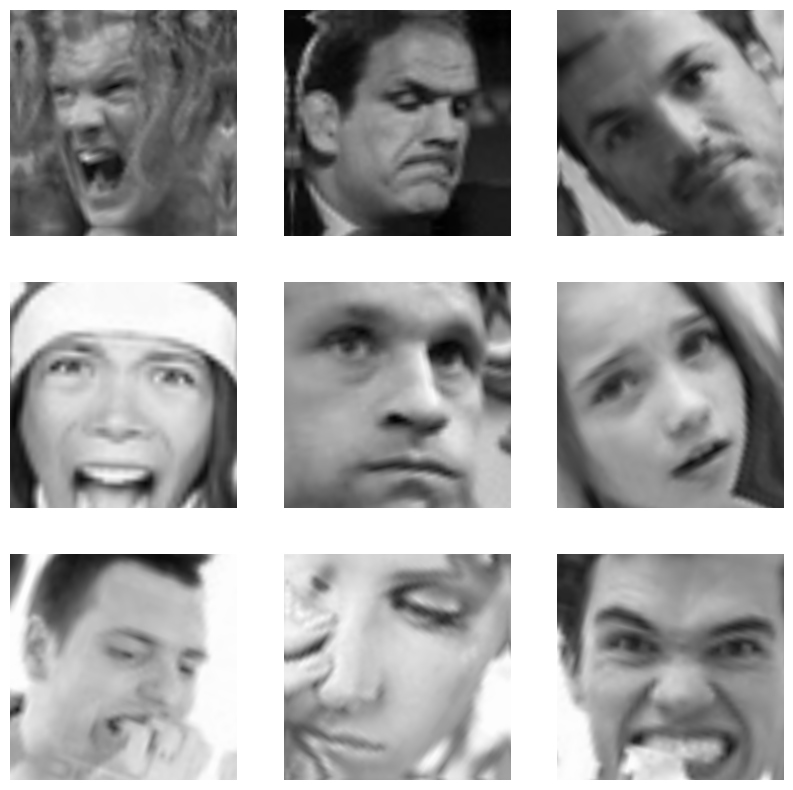

In [13]:
# Visualize Augmented Images
for images, labels in train_dataset.take(1):

    plt.figure(figsize=(10,10))

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i])

        plt.axis("off")

    plt.show()

In [14]:
# Improve Performance
AUTOTUNE = tf.data.AUTOTUNE


train_dataset = train_dataset.cache().shuffle(1000).prefetch(
    buffer_size=AUTOTUNE
)


test_dataset = test_dataset.cache().prefetch(
    buffer_size=AUTOTUNE
)